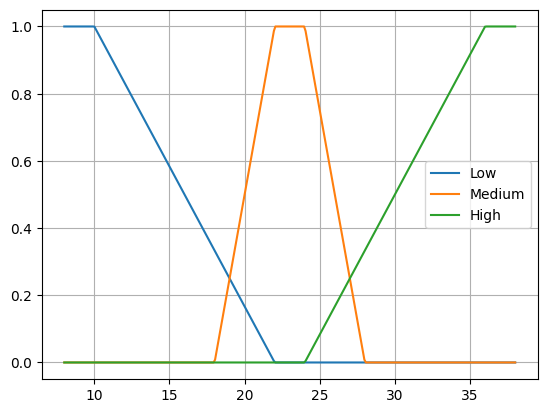

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

x = np.linspace(8, 38, 300)

low = fuzz.trapmf(x, [6, 6, 10, 22])
medium = fuzz.trapmf(x, [18, 22, 24, 28])
high = fuzz.trapmf(x, [24, 36, 40, 40])

plt.plot(x, low, label='Low')
plt.plot(x, medium, label='Medium')
plt.plot(x, high, label='High')

plt.legend()
plt.grid()
plt.show()

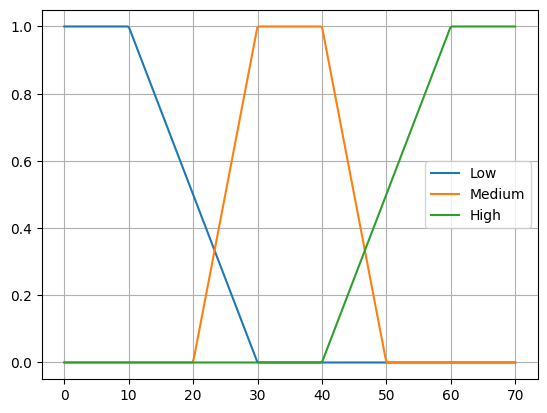

In [26]:
x = np.linspace(0, 70, 300)

low = fuzz.trapmf(x, [0, 0, 10, 30])
medium = fuzz.trapmf(x, [20, 30, 40, 50])
high = fuzz.trapmf(x, [40, 60, 70, 70])

plt.plot(x, low, label='Low')
plt.plot(x, medium, label='Medium')
plt.plot(x, high, label='High')

plt.legend()
plt.grid()
plt.show()

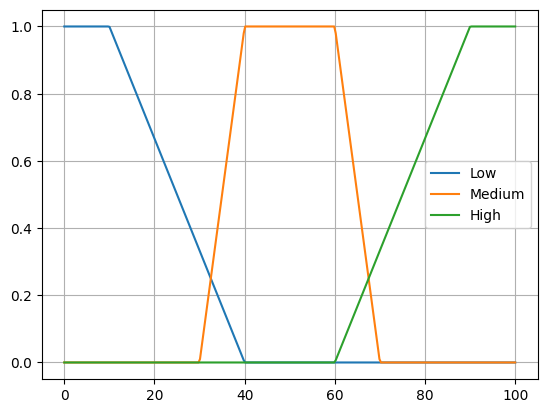

In [27]:
x = np.linspace(0, 100, 300)

low = fuzz.trapmf(x, [0, 0, 10, 40])
medium = fuzz.trapmf(x, [30, 40, 60, 70])
high = fuzz.trapmf(x, [60, 90, 100, 100])

plt.plot(x, low, label='Low')
plt.plot(x, medium, label='Medium')
plt.plot(x, high, label='High')

plt.legend()
plt.grid()
plt.show()

In [29]:
import numpy as np

# -----------------------------
# 1. Trapezoidal Membership Function
# -----------------------------
def trapmf(x, a, b, c, d):
    return np.maximum(
        np.minimum(
            np.minimum((x - a) / (b - a + 1e-9), 1),
            (d - x) / (d - c + 1e-9)
        ),
        0
    )

# -----------------------------
# 2. Universe
# -----------------------------
z = np.linspace(0, 100, 1000)  # fan speed domain

# -----------------------------
# 3. Output Membership Functions
# -----------------------------
fan_low = trapmf(z, 10, 10, 10, 40)
fan_med = trapmf(z, 30, 50, 60, 80)
fan_high = trapmf(z, 60, 80, 100, 100)

# -----------------------------
# 4. Input Values
# -----------------------------
temp = 25
hum = 80

# -----------------------------
# 5. Fuzzification
# -----------------------------
temp_med = trapmf(temp, 18, 22, 24, 28)
temp_high = trapmf(temp, 24, 36, 40, 40)
hum_med = trapmf(hum, 20, 30, 40, 50)
hum_high = trapmf(hum, 40, 60, 70, 70)

print(f"Temperature Medium: {temp_med:.2f}")
print(f"Temperature High: {temp_high:.2f}")
print(f"Humidity Medium: {hum_med:.2f}")
print(f"Humidity High: {hum_high:.2f}")

# -----------------------------
# 6. Rule Evaluation (MIN)
# -----------------------------
rule1 = min(temp_med, hum_med)   # -> Medium fan
rule2 = min(temp_med, hum_high)  # -> High fan
rule3 = min(temp_high, hum_med)  # -> High fan
rule4 = min(temp_high, hum_high) # -> High fan

print(f"Rule 1 (Medium Fan): {rule1:.2f}")
print(f"Rule 2 (High Fan): {rule2:.2f}")
print(f"Rule 3 (High Fan): {rule3:.2f}")
print(f"Rule 4 (High Fan): {rule4:.2f}")

# -----------------------------
# 7. Implication (Clipping)
# -----------------------------
fan_med_clipped = np.minimum(fan_med, rule1)
fan_high_clipped = np.minimum(fan_high, rule2)

# -----------------------------
# 8. Aggregation (MAX)
# -----------------------------
aggregated = np.maximum(fan_med_clipped, fan_high_clipped)

# -----------------------------
# 9. Centroid Defuzzification
# -----------------------------
def centroid(x, mf):
    return np.sum(x * mf) / np.sum(mf)

result = centroid(z, aggregated)

# -----------------------------
# 10. Output
# -----------------------------
print(f"Fan Speed (centroid) = {result:.2f}%")

Temperature Medium: 0.75
Temperature High: 0.08
Humidity Medium: 0.00
Humidity High: 0.00
Rule 1 (Medium Fan): 0.00
Rule 2 (High Fan): 0.00
Rule 3 (High Fan): 0.00
Rule 4 (High Fan): 0.00
Fan Speed (centroid) = nan%


/var/folders/hs/g8qztd0j147_kvflxr1pr8yc0000gn/T/ipykernel_34986/3121838727.py:74: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum(x * mf) / np.sum(mf)


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# -----------------------------
# 1. Define Universes
# -----------------------------
x_temp = np.arange(0, 41, 1)
x_hum = np.arange(0, 71, 1)
x_fan = np.arange(0, 101, 1)

# -----------------------------
# 2. Create Fuzzy Variables
# -----------------------------
temperature = ctrl.Antecedent(x_temp, 'temperature')
humidity = ctrl.Antecedent(x_hum, 'humidity')
fan = ctrl.Consequent(x_fan, 'fan')

# -----------------------------
# 3. Membership Functions (YOUR VALUES)
# -----------------------------
# Temperature
temperature['low'] = fuzz.trapmf(x_temp, [0, 0, 10, 22])
temperature['medium'] = fuzz.trapmf(x_temp, [18, 22, 24, 28])
temperature['high'] = fuzz.trapmf(x_temp, [24, 36, 40, 40])

# Humidity
humidity['low'] = fuzz.trapmf(x_hum, [0, 0, 10, 30])
humidity['medium'] = fuzz.trapmf(x_hum, [20, 30, 40, 50])
humidity['high'] = fuzz.trapmf(x_hum, [40, 60, 70, 70])

# Fan Speed
fan['low'] = fuzz.trapmf(x_fan, [0, 0, 10, 40])
fan['medium'] = fuzz.trapmf(x_fan, [30, 40, 60, 70])
fan['high'] = fuzz.trapmf(x_fan, [60, 90, 100, 100])

# -----------------------------
# 4. Define Rules (Mamdani)
# -----------------------------
rules = [
    ctrl.Rule(temperature['low'] & humidity['low'], fan['low']),
    ctrl.Rule(temperature['low'] & humidity['medium'], fan['medium']),
    ctrl.Rule(temperature['low'] & humidity['high'], fan['high']),

    ctrl.Rule(temperature['medium'] & humidity['low'], fan['medium']),
    ctrl.Rule(temperature['medium'] & humidity['medium'], fan['medium']),
    ctrl.Rule(temperature['medium'] & humidity['high'], fan['high']),

    ctrl.Rule(temperature['high'] & humidity['low'], fan['high']),
    ctrl.Rule(temperature['high'] & humidity['medium'], fan['high']),
    ctrl.Rule(temperature['high'] & humidity['high'], fan['high']),
]

# -----------------------------
# 5. Control System
# -----------------------------
fan_ctrl = ctrl.ControlSystem(rules)
fan_sim = ctrl.ControlSystemSimulation(fan_ctrl)

# -----------------------------
# 6. Input Values (CHANGE HERE)
# -----------------------------
fan_sim.input['temperature'] = 25
fan_sim.input['humidity'] = 45

# -----------------------------
# 7. Compute (Mamdani + Centroid)
# -----------------------------
fan_sim.compute()
print(fan_sim.output)

# -----------------------------
# 8. Output
# -----------------------------
print(f"Fan Speed = {fan_sim.output['fan']:.2f}%")

# -----------------------------
# 9. Visualization
# -----------------------------
fan.view(sim=fan_sim)

TypeError: '_InputAcceptor' object is not subscriptable

Fan Speed = 53.27%


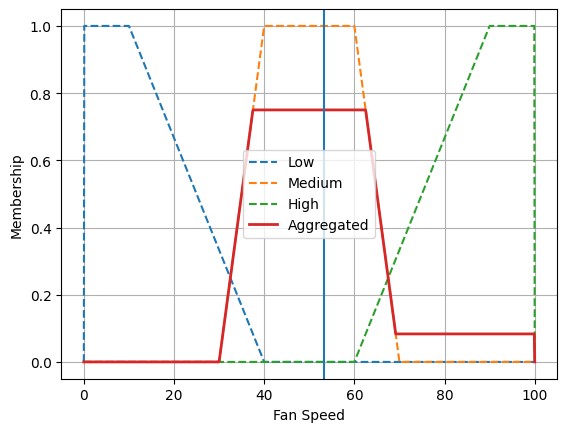

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def trapmf(x, a, b, c, d):
    x = np.array(x)
    return np.maximum(
        np.minimum(
            np.minimum((x - a) / (b - a + 1e-9), 1),
            (d - x) / (d - c + 1e-9)
        ),
        0
    )

x_temp = np.linspace(0, 40, 1000)
x_hum = np.linspace(0, 70, 1000)
x_fan = np.linspace(0, 100, 1000)

temp_low = trapmf(x_temp, 0, 0, 10, 22)
temp_med = trapmf(x_temp, 18, 22, 24, 28)
temp_high = trapmf(x_temp, 24, 36, 40, 40)

hum_low = trapmf(x_hum, 0, 0, 10, 30)
hum_med = trapmf(x_hum, 20, 30, 40, 50)
hum_high = trapmf(x_hum, 40, 60, 70, 70)

fan_low = trapmf(x_fan, 0, 0, 10, 40)
fan_med = trapmf(x_fan, 30, 40, 60, 70)
fan_high = trapmf(x_fan, 60, 90, 100, 100)

# Values
temp_val = 25
hum_val = 38

# Fuzzification
def interp_membership(x, mf, val):
    return np.interp(val, x, mf)

t_low = interp_membership(x_temp, temp_low, temp_val)
t_med = interp_membership(x_temp, temp_med, temp_val)
t_high = interp_membership(x_temp, temp_high, temp_val)

h_low = interp_membership(x_hum, hum_low, hum_val)
h_med = interp_membership(x_hum, hum_med, hum_val)
h_high = interp_membership(x_hum, hum_high, hum_val)

# Rule Evaluation (MIN)
rules = []

rules.append((min(t_low, h_low), fan_low))
rules.append((min(t_low, h_med), fan_low))
rules.append((min(t_low, h_high), fan_med))

rules.append((min(t_med, h_low), fan_low))
rules.append((min(t_med, h_med), fan_med))
rules.append((min(t_med, h_high), fan_high))

rules.append((min(t_high, h_low), fan_med))
rules.append((min(t_high, h_med), fan_high))
rules.append((min(t_high, h_high), fan_high))

# Aggregation (MAX)
aggregated = np.zeros_like(x_fan)

for strength, mf in rules:
    clipped = np.minimum(strength, mf)
    aggregated = np.maximum(aggregated, clipped)

# Centroid Defuzzification
def centroid(x, mf):
    return np.sum(x * mf) / np.sum(mf)

result = centroid(x_fan, aggregated)

print(f"Fan Speed = {result:.2f}%")

# Visualization
plt.figure()
plt.plot(x_fan, fan_low, '--', label='Low')
plt.plot(x_fan, fan_med, '--', label='Medium')
plt.plot(x_fan, fan_high, '--', label='High')
plt.plot(x_fan, aggregated, linewidth=2, label='Aggregated')

plt.axvline(result)
plt.xlabel("Fan Speed")
plt.ylabel("Membership")
plt.legend()
plt.grid()

plt.show()